In [6]:
import re
import numpy as np
import pandas as pd
import re

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

from collections import Counter

from flair.models import TextClassifier
from flair.data import Sentence
flair_model = TextClassifier.load("sentiment")

from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np

import os
import sys

from transformers import pipeline

df = pd.read_csv('english_bg3_reviews_no_spam.csv', sep=';', encoding='utf-8')
df = df.dropna(subset=['clean_review']).reset_index(drop=True) # wyrzucamy nulle
df.head()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\huber\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,review_id,review,voted_up,author_steamid,date_str,review_length,review_word_count,clean_review,is_spam_label,num_emojis,low_quality,is_spam
0,209490463,The greatest game of all time. It simply is. \r\n,True,76561198842852247,2025-11-17 20:17:24,43,9,the greatest game of all time it simply is,0,0,0,0
1,209488275,The dude trying to bite me at night was messed...,True,76561198335095296,2025-11-17 19:45:37,55,12,the dude trying to bite me at night was messed...,0,0,0,0
2,209488128,"This is probably a great solo game, but my hop...",False,76561198031957731,2025-11-17 19:43:28,131,29,this is probably a great solo game but my hope...,0,0,0,0
3,209487979,One of the best RPG's of the last decade,True,76561198140742800,2025-11-17 19:41:16,39,9,one of the best rpgs of the last decade,0,0,0,0
4,209482559,Definitely one of the best games I've played i...,True,76561198024036703,2025-11-17 18:19:29,61,12,definitely one of the best games ive played in...,0,0,0,0


In [7]:
# tokenizacja recenzji

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    tokens = [w for w in text.split() if len(w) > 2]
    return tokens

df["tokens"] = df["clean_review"].apply(tokenize)
df["tokens"].head()


0             [the, greatest, game, all, time, simply]
1    [the, dude, trying, bite, night, was, messed, ...
2    [this, probably, great, solo, game, but, hope,...
3            [one, the, best, rpgs, the, last, decade]
4    [definitely, one, the, best, games, ive, playe...
Name: tokens, dtype: object

In [8]:

# Kolumna z tekstem
TEXT_COL = "clean_review" if "clean_review" in df.columns else "review"

# Kolumna z etykietą 0/1 (Steam)
LABEL_COL = "voted_up"

assert TEXT_COL in df.columns, f"Brakuje kolumny z tekstem: {TEXT_COL}"
assert LABEL_COL in df.columns, f"Brakuje kolumny z etykietą: {LABEL_COL}"

df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)
df = df[df[TEXT_COL].str.strip().ne("")].reset_index(drop=True)

df[LABEL_COL] = df[LABEL_COL].astype(int)

df[[TEXT_COL, LABEL_COL]].head()


,clean_review,voted_up
0,the greatest game of all time it simply is,1
1,the dude trying to bite me at night was messed...,1
2,this is probably a great solo game but my hope...,0
3,one of the best rpgs of the last decade,1
4,definitely one of the best games ive played in...,1


In [9]:
# Wklej swoje słowniki:
keyword_categories = {
    'grafika': ['graf', 'visual', 'graph', 'art', 'design', 'textures', 'lighting', 'shaders', 'models', 'animation', 'animations', 'resolution', '4k', 'hd', 'detail', 'detailed', 'details', 'aesthetic', 'aesthetics', 'style', 'visuals', 'render', 'rendering'],
    'soundtrack': ['sound', 'muzyk', 'music', 'audio', 'sfx', 'soundtrack', 'voice acting', 'va', 'voices', 'vo', 'sound design', 'ost', 'official soundtrack', 'ambient', 'sound quality', 'volume', 'sound effects'],
    'fabuła': ['fab', 'story', 'plot', 'narrat', 'questline', 'quests', 'main story', 'side story', 'side quests', 'lore', 'dialogue choices', 'scenario', 'writing', 'plot twist', 'plot twists'],
    'mechanika': ['mechan', 'gameplay', 'multiplay', 'singleplay', 'coop', 'co-op', 'combat', 'controls', 'crafting', 'skills', 'builds', 'exploration', 'movement', 'jumping'],
    'postacie': ['posta', 'charact', 'bohater', 'hero', 'cosplay', 'npc', 'villains', 'protagonist', 'antagonist', 'character desing', 'personality'],
    'dialogi': ['dialog', 'rozmow', 'funny', 'humor', 'comedy', 'humour', 'banter', 'conversation', 'jokes', 'sarcasm'],
    'świat': ['świat', 'world', 'setting', 'immers', 'environ', 'open world', 'map', 'locations', 'areas', 'biomes', 'exploration', 'atmosphere'],
    'klimat': ['klimat', 'atmos', 'vibe', 'mood', 'creepy', 'cozy', 'intense', 'tense', 'feeling'],
    'bugi': ['bug', 'glitch', 'crash', 'error', 'problem', 'issue', 'lag', 'freeze', 'unstable', 'not working', 'corrupted', 'bugs', 'buggy'],
    'optymalizacja': ['optymal', 'perform', 'fps', 'performance', 'loading time', 'cpu', 'gpu', 'ram', 'optimization'],
    'sterowanie': ['sterow', 'control', 'keyb', 'pad', 'mouse', 'controls', 'keybinds', 'controller', 'keyboard', 'shortcut', 'shortcuts', 'sensitivity'],
    'balans': ['balan', 'diff', 'eas', 'hard', 'challeng', 'easy', 'difficult', 'scaling', 'overpowered', 'op', 'nerf', 'challenge'],
    'interfejs': ['interfejs', 'interface', 'ui', 'hud', 'menu', 'layout', 'navigation'],
    'cena': ['cen', 'price', 'koszt', 'cost', 'worth it', 'worth', 'expensive', 'cheap', 'overpriced', 'deal', 'discount', 'sale']
}
expectation_categories = {
    "oczekiwania": [
    "future", "next game", "next one", "sequel", "follow-up",
    "hope", "wish", "would like", "i'd like", "i want",
    "should add" "should include", "please add",
    "needs fixing", "needs update", "needs patch", "needs patching",
    "expansion", "dlc", "more content", "i need", "i require",
    "looking forward", "can't wait", "excited for", "i would love",
    "i'd love", "plan to", "please include", "looking forward to",
    "waiting for", "looking for", "when will"
    ]
}


print("theme:", len(keyword_categories), "expect:", len(expectation_categories))


theme: 14 expect: 1


In [10]:
# poszerzanie ręcznie stworzonego słownika tematycznego o często występujące w recenzjach słowa
all_words = Counter()
for tokens in df["tokens"]:
    all_words.update(tokens)

most_common_words = all_words.most_common(400)

def auto_assign_category(word, keyword_categories):
    word_lower = word.lower()
    for category, fragments in keyword_categories.items():
        for frag in fragments:
            frag_lower = frag.lower()
            if len(frag_lower) < 4:
                continue

            if frag_lower in word_lower:
                return category
    return None

new_keywords = {}
for word, count in most_common_words:
    cat = auto_assign_category(word, keyword_categories)
    if cat:
        if word not in keyword_categories[cat]:
            new_keywords.setdefault(cat, []).append(word)

for cat, words in new_keywords.items():
    keyword_categories[cat].extend(words)

print("Nowe słowa dodane do słownika kategorii:")
print(new_keywords)

Nowe słowa dodane do słownika kategorii:
{'postacie': ['characters', 'character'], 'balans': ['different'], 'mechanika': ['mechanics', 'multiplayer'], 'grafika': ['graphics'], 'dialogi': ['dialogue'], 'świat': ['immersive'], 'fabuła': ['storytelling', 'explore', 'narrative'], 'bugi': ['issues']}


In [11]:

# poszerzanie ręcznie stworzonego oczekiwań słownika o często występujące w recenzjach słowa
all_words = Counter()
for tokens in df["tokens"]:
    all_words.update(tokens)

most_common_words = all_words.most_common(400)

def auto_assign_exp_category(word, expectation_categories):
    word_lower = word.lower()
    for category, fragments in expectation_categories.items():
        for frag in fragments:
            frag_lower = frag.lower()
            if len(frag_lower) < 4:
                continue

            if frag_lower in word_lower:
                return category
    return None

new_exp_keywords = {}
for word, count in most_common_words:
    cat = auto_assign_exp_category(word, expectation_categories)
    if cat:
        if word not in expectation_categories[cat]:
            new_exp_keywords.setdefault(cat, []).append(word)

for cat, words in new_exp_keywords.items():
    expectation_categories[cat].extend(words)

print("Nowe słowa dodane do słownika oczekiwań:")
print(new_exp_keywords)

Nowe słowa dodane do słownika oczekiwań:
{}


In [12]:
ASPECT_DICT = {}
for k, v in keyword_categories.items():
    ASPECT_DICT[f"theme::{k}"] = v

for k, v in expectation_categories.items():
    ASPECT_DICT[f"expect::{k}"] = v

GENERAL_ASPECT = "general::other"

len(ASPECT_DICT), list(ASPECT_DICT.keys())[:10]


(15,
 ['theme::grafika',
  'theme::soundtrack',
  'theme::fabuła',
  'theme::mechanika',
  'theme::postacie',
  'theme::dialogi',
  'theme::świat',
  'theme::klimat',
  'theme::bugi',
  'theme::optymalizacja'])

In [13]:
def _compile_kw_pattern(kw: str) -> re.Pattern:
    kw = str(kw).strip().lower()
    kw_escaped = re.escape(kw).replace(r"\ ", r"\s+")
    return re.compile(rf"\b{kw_escaped}\b", flags=re.IGNORECASE)

ASPECT_PATTERNS = {
    aspect: [_compile_kw_pattern(kw) for kw in kws if str(kw).strip()]
    for aspect, kws in ASPECT_DICT.items()
}

def count_aspect_tokens(text: str) -> dict[str, int]:
    t = str(text).lower()
    counts = {}
    for aspect, patterns in ASPECT_PATTERNS.items():
        c = 0
        for pat in patterns:
            c += len(pat.findall(t))
        if c > 0:
            counts[aspect] = c
    return counts

# szybki test
example = "I like music. Music is great. Music is wonderful. I don't like the price though."
print(count_aspect_tokens(example))


{'theme::soundtrack': 3, 'theme::cena': 1}


In [14]:
def compute_global_weights(df: pd.DataFrame, text_col: str) -> dict[str, float]:
    global_counts = {a: 0 for a in ASPECT_DICT.keys()}
    general_count = 0

    for txt in df[text_col].tolist():
        c = count_aspect_tokens(txt)
        if not c:
            general_count += 1
        else:
            for a, n in c.items():
                global_counts[a] += int(n)

    global_counts[GENERAL_ASPECT] = int(general_count)

    total = sum(global_counts.values())
    if total == 0:
        return {GENERAL_ASPECT: 1.0}

    return {a: global_counts[a] / total for a in global_counts}

GLOBAL_W = compute_global_weights(df, TEXT_COL)

# top 10 global
pd.DataFrame(sorted(GLOBAL_W.items(), key=lambda x: x[1], reverse=True), columns=["aspect", "global_weight"]).head(10)


,aspect,global_weight
0,general::other,0.208374
1,theme::fabuła,0.161325
2,theme::postacie,0.121135
3,theme::mechanika,0.119045
4,theme::świat,0.063526
5,theme::balans,0.061035
6,theme::grafika,0.059134
7,expect::oczekiwania,0.047937
8,theme::cena,0.047159
9,theme::bugi,0.033448


In [15]:
def compute_local_weights(text: str) -> dict[str, float]:
    counts = count_aspect_tokens(text)
    if not counts:
        return {GENERAL_ASPECT: 1.0}
    total = sum(counts.values())
    return {a: counts[a] / total for a in counts}

df["local_weight"] = df["clean_review"].apply(compute_local_weights)

def compute_total_weights(text: str, global_w: dict[str, float]) -> dict[str, float]:
    local_w = compute_local_weights(text)

    total_w = {}
    for a, lw in local_w.items():
        gw = global_w.get(a, 0.0)
        total_w[a] = float(gw * lw)

    s = sum(total_w.values())
    if s > 0:
        total_w = {a: w / s for a, w in total_w.items()}
    else:
        total_w = {GENERAL_ASPECT: 1.0}

    return total_w


In [16]:
SENT_SPLIT_RE = re.compile(r'(?<=[.!?])\s+')

def split_sentences(text: str) -> list[str]:
    text = str(text).strip()
    return [] if not text else SENT_SPLIT_RE.split(text)

def extract_aspect_texts(text: str) -> dict[str, str]:
    """
    Zwraca aspekt -> tekst (kontekst) jako zlepione zdania zawierające keywordy aspektu.
    Jeśli nic nie pasuje: GENERAL_ASPECT -> cały tekst.
    """
    t = str(text).strip()
    if not t:
        return {GENERAL_ASPECT: ""}

    sents = split_sentences(t)
    buckets = {}

    for s in sents:
        s_l = s.lower()
        for a, patterns in ASPECT_PATTERNS.items():
            if any(p.search(s_l) for p in patterns):
                buckets.setdefault(a, []).append(s)

    if not buckets:
        return {GENERAL_ASPECT: t}

    return {a: " ".join(v) for a, v in buckets.items()}


In [17]:
X = df[TEXT_COL].values
y = df[LABEL_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lr_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=3,
        max_features=120_000
    )),
    ("lr", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear"
    ))
])

lr_pipe.fit(X_train, y_train)

pred = lr_pipe.predict(X_test)
print("ACC:", accuracy_score(y_test, pred))
print("F1 :", f1_score(y_test, pred))
print(classification_report(y_test, pred))


ACC: 0.9459000942507069
F1 : 0.970992520719628
              precision    recall  f1-score   support

           0       0.49      0.78      0.60       548
           1       0.99      0.95      0.97     10062

    accuracy                           0.95     10610
   macro avg       0.74      0.87      0.79     10610
weighted avg       0.96      0.95      0.95     10610



In [20]:
# wcześniej eksperymentowanie - teraz smote
from imblearn.over_sampling import SMOTE


X_txt = df[TEXT_COL].fillna("").astype(str).values
y = df[LABEL_COL].astype(int).values

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_txt,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_features=120_000
)

X_train = tfidf.fit_transform(X_train_txt)
X_test = tfidf.transform(X_test_txt)


smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

lr = LogisticRegression(
    max_iter=2000,
    solver="liblinear"
)
lr.fit(X_train_bal, y_train_bal)

#ewaluacja
pred = lr.predict(X_test)
print("ACC:", accuracy_score(y_test, pred))
print("F1 :", f1_score(y_test, pred))
print(classification_report(y_test, pred))


ACC: 0.9533459000942507
F1 : 0.9751393701973783
              precision    recall  f1-score   support

           0       0.53      0.74      0.62       548
           1       0.99      0.96      0.98     10062

    accuracy                           0.95     10610
   macro avg       0.76      0.85      0.80     10610
weighted avg       0.96      0.95      0.96     10610



--- WYNIKI OPTYMALIZACJI ---
Standardowy próg (0.50): F1 ≈ 0.975
Optymalny próg:          0.2592
Przewidywany max F1:     0.9808

RAPORT KLASYFIKACJI (Dla progu 0.2592)
              precision    recall  f1-score   support

           0       0.67      0.58      0.62       548
           1       0.98      0.98      0.98     10062

    accuracy                           0.96     10610
   macro avg       0.82      0.78      0.80     10610
weighted avg       0.96      0.96      0.96     10610



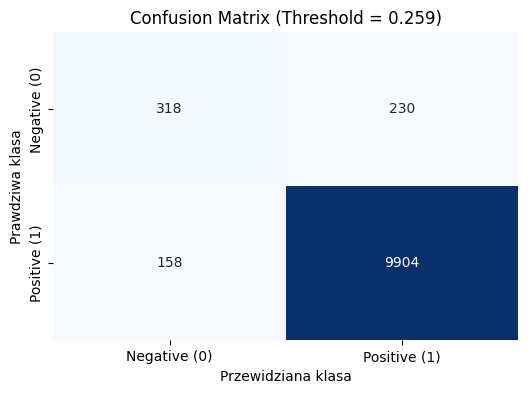

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix

# 1. Pobieramy prawdopodobieństwa zamiast sztywnych etykiet 0/1
# (Model jest już wytrenowany na danych ze SMOTE)
y_probs = lr.predict_proba(X_test)[:, 1]

# 2. Obliczamy krzywą Precision-Recall i szukamy optymalnego progu
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Obliczamy F1 dla każdego możliwego progu
# (dodajemy epsilon 1e-10, żeby uniknąć dzielenia przez zero)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# Znajdujemy indeks najlepszego wyniku
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"--- WYNIKI OPTYMALIZACJI ---")
print(f"Standardowy próg (0.50): F1 ≈ {f1_score(y_test, lr.predict(X_test)):.3f}")
print(f"Optymalny próg:          {best_threshold:.4f}")
print(f"Przewidywany max F1:     {best_f1:.4f}")

# 3. Generujemy nowe predykcje z użyciem wyliczonego progu
y_pred_optimized = (y_probs >= best_threshold).astype(int)

print("\n" + "="*60)
print(f"RAPORT KLASYFIKACJI (Dla progu {best_threshold:.4f})")
print("="*60)
print(classification_report(y_test, y_pred_optimized))

# macierz pomyłek
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title(f'Confusion Matrix (Threshold = {best_threshold:.3f})')
plt.xlabel('Przewidziana klasa')
plt.ylabel('Prawdziwa klasa')
plt.show()

In [23]:
POS_THR = 0.55
NEG_THR = 0.45

def proba_to_score(p_pos: float) -> float:
    return float(2.0 * p_pos - 1.0)  # [-1, 1]

def proba_to_label_012(p_pos: float) -> int:
    # 0=neg, 2=neutral, 1=pos
    if p_pos >= POS_THR:
        return 1
    if p_pos <= NEG_THR:
        return 0
    return 2


In [ ]:
def absa_predict_with_global_local_weights(df_in: pd.DataFrame, batch_size: int = 512) -> pd.DataFrame:
    texts = df_in[TEXT_COL].fillna("").astype(str).tolist()

    tasks = []
    aspects_per_review = []
    weights_per_review = []
    aspect_texts_per_review = []
    
    for i, txt in enumerate(texts):
        a_texts = extract_aspect_texts(txt)
        aspects = list(a_texts.keys())

        w_total = compute_total_weights(txt, GLOBAL_W)

        # ograniczenie wag do aspektów
        s = sum(w_total.get(a, 0.0) for a in aspects)
        if s > 0:
            w_total = {a: w_total.get(a, 0.0) / s for a in aspects}
        else:
            # fallback
            a_texts = {GENERAL_ASPECT: txt}
            aspects = [GENERAL_ASPECT]
            w_total = {GENERAL_ASPECT: 1.0}

        aspects_per_review.append(aspects)
        weights_per_review.append(w_total)
        aspect_texts_per_review.append(a_texts)

        for a in aspects:
            tasks.append((i, a, a_texts[a]))

    proba_map = {}
    for start in tqdm(range(0, len(tasks), batch_size), desc="ABSA LR batches"):
        chunk = tasks[start:start + batch_size]
        chunk_texts = [t[2] for t in chunk]

        p_pos = lr_pipe.predict_proba(chunk_texts)[:, 1]
        for (i, a, _), p in zip(chunk, p_pos):
            proba_map[(i, a)] = float(p)

    # agregacja wagowa
    out_aspect_sent = []
    out_aspect_w = []
    out_score = []
    out_label = []

    for i in range(len(df_in)):
        aspects = aspects_per_review[i]
        w = weights_per_review[i]

        aspect_sent = {}
        score = 0.0

        for a in aspects:
            p = proba_map.get((i, a), 0.5)
            aspect_sent[a] = proba_to_label_012(p)
            score += w.get(a, 0.0) * proba_to_score(p)

        out_aspect_sent.append(aspect_sent)
        out_aspect_w.append(w)
        out_score.append(float(score))

        # finalna etykieta na bazie score
        if score >= 0.1:
            out_label.append(1)
        elif score <= -0.1:
            out_label.append(0)
        else:
            out_label.append(2)

    df_out = df_in.copy()
    df_out["absa_aspect_sentiments"] = out_aspect_sent
    df_out["absa_aspect_weights_global_local"] = out_aspect_w
    df_out["absa_score_global_local"] = out_score
    df_out["absa_label_global_local"] = out_label

    return df_out

df_absa = absa_predict_with_global_local_weights(df, batch_size=512)
df_absa[[TEXT_COL, "absa_aspect_weights_global_local", "absa_score_global_local", "absa_label_global_local"]].head(100)


ABSA LR batches:   0%|          | 0/182 [00:00<?, ?it/s]

,clean_review,absa_aspect_weights_global_local,absa_score_global_local,absa_label_global_local
0,the greatest game of all time it simply is,{'general::other': 1.0},0.950708,1
1,the dude trying to bite me at night was messed...,{'general::other': 1.0},0.322593,1
2,this is probably a great solo game but my hope...,"{'theme::mechanika': 0.7129211368341803, 'expe...",-0.533616,0
3,one of the best rpgs of the last decade,{'general::other': 1.0},0.991284,1
4,definitely one of the best games ive played in...,{'general::other': 1.0},0.998138,1
...,...,...,...,...
95,would kick the squirrel and stroke the empero...,{'general::other': 1.0},0.777969,1
96,i will remember this game when im old and deme...,{'general::other': 1.0},0.556513,1
97,its good uk i fuhhh with it but like that no n...,{'general::other': 1.0},0.170896,1
98,i am not a fan of lengthy rpg games and even t...,"{'theme::fabuła': 0.4018003913894325, 'theme::...",0.811640,1


In [ ]:
y_true = df_absa[LABEL_COL].astype(int)

mask = df_absa["absa_label_global_local"].isin([0, 1])
y_pred = df_absa.loc[mask, "absa_label_global_local"].astype(int)
y_true2 = y_true.loc[mask]

print("ACC:", accuracy_score(y_true2, y_pred))
print("F1 :", f1_score(y_true2, y_pred))
print(classification_report(y_true2, y_pred))
print("Pokrycie:", round(mask.mean() * 100, 2), "%")


ABSA LR (bez neutralnych) – metryki:
ACC: 0.9694095055208833
F1 : 0.9836402288108613
              precision    recall  f1-score   support

           0       0.64      0.96      0.76      2705
           1       1.00      0.97      0.98     49370

    accuracy                           0.97     52075
   macro avg       0.82      0.96      0.87     52075
weighted avg       0.98      0.97      0.97     52075

Pokrycie (bez neutral): 98.17 %


In [ ]:
# zapis globalnych wag
pd.DataFrame(sorted(GLOBAL_W.items(), key=lambda x: x[1], reverse=True), columns=["aspect", "global_weight"]) \
  .to_csv("absa_global_weights.csv", sep=";", index=False, encoding="utf-8")

# zapis wyników ABSA
df_absa.to_csv("english_bg3_reviews_absa_lr_global_local.csv", sep=";", index=False, encoding="utf-8")


Zapisano:
- absa_global_weights.csv
- english_bg3_reviews_absa_lr_global_local.csv


In [28]:
import joblib
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ('vectorizer', tfidf),
    ('classifier', lr)
])

model_filename = 'bg3_absa_model.pkl'
joblib.dump(final_pipeline, model_filename)

print(f"Zapisano kompletny model jako '{model_filename}'")

Zapisano kompletny model jako 'bg3_absa_model.pkl'
